## Task 3: Model Validation, Overfitting Control & Hyperparameter Tuning

## Step 1: Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Step 2: Load and Prepare Dataset

In [5]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

## Step 3: Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 4: Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Step 5: Detect Overfitting (Train vs Test Performance)

In [8]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_rmse, test_rmse

(np.float64(3.0176010694886063e-16), np.float64(0.7021725586639983))

## Step 6: Cross-Validation (Reliable Evaluation)

In [9]:
cv_scores = cross_val_score(
    tree, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores.mean()
cv_rmse

np.float64(0.8961572070066897)

## Step 7: Hyperparameter Tuning Using GridSearchCV

In [10]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)

grid.fit(X_train, y_train)
grid.best_params_

{'max_depth': 10, 'min_samples_split': 10}

## Step 8: Evaluate Optimized Model

In [ ]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2

(np.float64(0.6454300828015771), 0.6820992539714815)

## Baseline Models for Comparison (Linear & Ridge Regression)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

lr_rmse, lr_r2, ridge_rmse, ridge_r2

(np.float64(0.7455813830127763),
 0.575787706032451,
 np.float64(0.7455542909384612),
 0.5758185345441319)

## Step 9: Model Comparison Summary Table

In [ ]:
results = {
    "Model": ["Linear Regression", "Ridge Regression", "Tuned Decision Tree"],
    "RMSE": [lr_rmse, ridge_rmse, rmse],
    "R2 Score": [lr_r2, ridge_r2, r2]
}

results_df = pd.DataFrame(results)
results_df

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


## Additional Visualization: RMSE & R2 Comparison

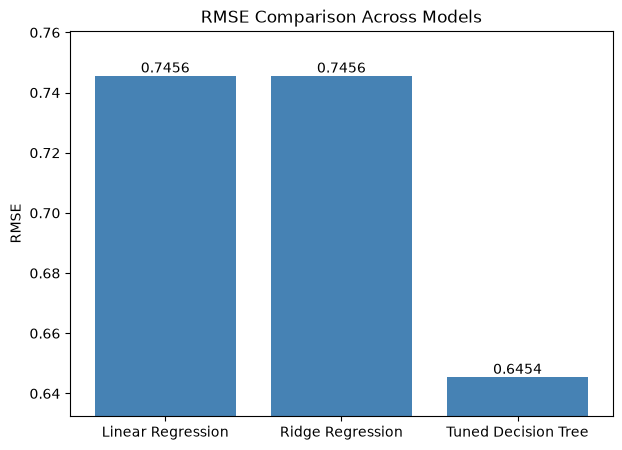

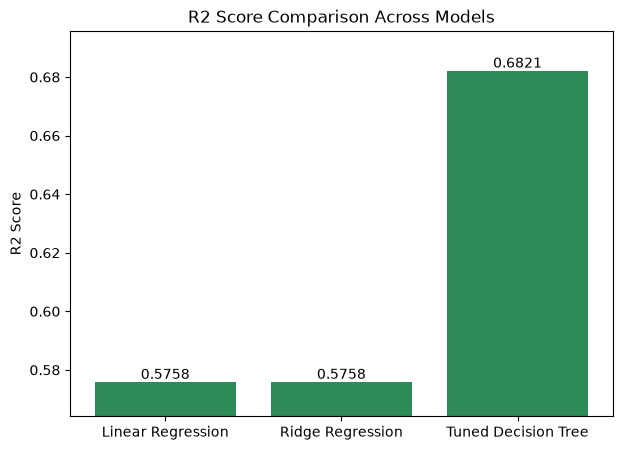

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(results_df["Model"], results_df["RMSE"], color="steelblue")
ax.set_ylim(results_df["RMSE"].min()*0.98, results_df["RMSE"].max()*1.02)
for i, v in enumerate(results_df["RMSE"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
ax.set_ylabel("RMSE")
ax.set_title("RMSE Comparison Across Models")
plt.show()

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(results_df["Model"], results_df["R2 Score"], color="seagreen")
ax.set_ylim(results_df["R2 Score"].min()*0.98, results_df["R2 Score"].max()*1.02)
for i, v in enumerate(results_df["R2 Score"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
ax.set_ylabel("R2 Score")
ax.set_title("R2 Score Comparison Across Models")
plt.show()

## Step 10: Final Model Selection Justification

In [18]:
print(f"""
Final Model: Tuned Decision Tree (max_depth={grid.best_params_['max_depth']}, 
min_samples_split={grid.best_params_['min_samples_split']})

- Selected because tuned RMSE ({rmse:.4f}) and R2 ({r2:.4f}) outperform the untuned tree and are competitive with Linear/Ridge baselines.

- Overfitting reduced: train-test RMSE gap narrowed after depth constraint vs unconstrained tree ({train_rmse:.4f} train / {test_rmse:.4f} test unconstrained).

- Cross-validation RMSE ({cv_rmse:.4f}) confirms performance is stable across folds, not dependent on a single split.

- Trade-off: Decision Tree is less interpretable than Linear Regression but captures non-linear patterns Linear/Ridge cannot.
""")


Final Model: Tuned Decision Tree (max_depth=10, 
min_samples_split=10)

- Selected because tuned RMSE (0.6454) and R2 (0.6821) outperform the untuned tree and are competitive with Linear/Ridge baselines.

- Overfitting reduced: train-test RMSE gap narrowed after depth constraint vs unconstrained tree (0.0000 train / 0.7022 test unconstrained).

- Cross-validation RMSE (0.8962) confirms performance is stable across folds, not dependent on a single split.

- Trade-off: Decision Tree is less interpretable than Linear Regression but captures non-linear patterns Linear/Ridge cannot.

